### **Predictive IT Infrastructure Analytics**
#### **Machine Learning Preparation & Predictive Modeling**

##### **Objetivo del Notebook**

##### El objetivo de este notebook es preparar los datos para el desarrollo de modelos de Machine Learning orientados a la detección temprana de incidencias en infraestructuras IT. Durante esta fase se realizará la selección y preparación de variables, la división de los datos en conjuntos de entrenamiento y prueba, el tratamiento del desbalanceo de clases y la aplicación de técnicas de escalado cuando sea necesario.

##### Asimismo, se entrenarán y evaluarán diferentes modelos predictivos con el fin de identificar patrones asociados a estados anómalos del sistema y analizar su capacidad para anticipar posibles incidencias operativas.

##### The objective of this notebook is to prepare the dataset for Machine Learning model development aimed at early detection of IT infrastructure incidents. This phase includes feature selection, train-test splitting, class imbalance analysis, and data scaling when required.

##### Additionally, different predictive models will be trained and evaluated to identify patterns associated with abnormal system states and assess their ability to anticipate potential operational incidents.

### **1. Exploración y Comprensión del Problema**
#### **1.1. Importación de Librerías**

In [81]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

try:
    import requests
except ImportError:
    import sys, importlib
    !{sys.executable} -m pip install --quiet requests
    requests = importlib.import_module("requests")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

#### **1.2. Carga del DataSet**

In [82]:
# Cargar el dataset transformado
df = pd.read_csv("../data/processed/Big_data_dataset_transformado.csv")

# Mostrar las primeras filas del DataFrame
df.head()

,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status,status_label,cpu_level,latency_level,temperature_level,cpu_utilization_norm,memory_usage_norm,network_latency_norm,temperature_norm,power_consumption_norm,system_pressure_score,pressure_level
0,40.581311,43.627674,36.769917,127.990769,646,3230,1500,0.065837,82.782403,255.012964,715.803096,0,Normal,Medium,High,Critical,0.374639,0.373570,0.638277,0.812102,0.820130,0.603744,Medium
1,95.317859,39.962089,10.041088,92.399198,626,3130,243,0.123481,59.424540,81.204822,86.158314,0,Normal,High,Medium,Warning,0.950982,0.332832,0.459386,0.452671,0.124683,0.464111,Medium
2,74.539424,25.853852,17.985345,192.935206,101,303,229,0.025459,90.973363,210.685067,545.755982,0,Normal,High,High,Critical,0.732198,0.176037,0.964702,0.938145,0.642764,0.690769,High
3,61.872556,64.654000,33.500751,44.576712,52,156,1574,0.178884,37.344280,90.398182,541.918137,0,Normal,Medium,Low,Normal,0.598823,0.607250,0.219020,0.112899,0.161467,0.339892,Medium
4,19.821771,52.896174,24.622378,117.983427,126,378,1164,0.167508,40.203942,87.099085,113.660688,0,Normal,Low,High,Normal,0.156053,0.476577,0.587978,0.156903,0.148267,0.305156,Low


#### **1.3. Exploración General**

In [83]:
# Dimensiones del DataFrame
df.shape

(10000, 23)

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cpu_utilization         10000 non-null  float64
 1   memory_usage            10000 non-null  float64
 2   disk_io                 10000 non-null  float64
 3   network_latency         10000 non-null  float64
 4   process_count           10000 non-null  int64  
 5   thread_count            10000 non-null  int64  
 6   context_switches        10000 non-null  int64  
 7   cache_miss_rate         10000 non-null  float64
 8   temperature             10000 non-null  float64
 9   power_consumption       10000 non-null  float64
 10  uptime                  10000 non-null  float64
 11  status                  10000 non-null  int64  
 12  status_label            10000 non-null  str    
 13  cpu_level               10000 non-null  str    
 14  latency_level           10000 non-null  str    
 1

In [85]:
df.describe()

,cpu_utilization,memory_usage,disk_io,network_latency,process_count,thread_count,context_switches,cache_miss_rate,temperature,power_consumption,uptime,status,cpu_utilization_norm,memory_usage_norm,network_latency_norm,temperature_norm,power_consumption_norm,system_pressure_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,51.945158,55.407689,25.502469,100.243963,517.236300,1811.330800,1038.862700,0.105904,62.376722,174.786780,500.381365,0.009700,0.494293,0.504490,0.498816,0.498099,0.499126,0.498965
std,27.324862,26.036510,14.051914,57.509924,275.023237,1167.260691,549.991836,0.055232,18.876303,71.993941,286.607554,0.098015,0.287715,0.289362,0.289057,0.290469,0.288065,0.128564
min,5.001105,10.014197,1.002358,1.001102,50.000000,100.000000,100.000000,0.010009,30.007482,50.043787,1.330765,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.089933
25%,28.401243,32.855122,13.433648,50.124593,277.000000,862.000000,559.000000,0.058344,45.980633,113.033926,251.078668,0.000000,0.246390,0.253847,0.246905,0.245795,0.252038,0.409046
50%,51.790219,55.530710,25.601337,100.506018,512.000000,1598.000000,1037.000000,0.105203,62.192959,173.836965,503.659313,0.000000,0.492662,0.505857,0.500133,0.495271,0.495326,0.501926
75%,75.300603,78.083130,37.489019,149.676135,755.000000,2598.500000,1508.000000,0.154801,78.975899,236.487255,746.406942,0.000000,0.740212,0.756498,0.747272,0.753528,0.746004,0.586370
max,99.973179,99.993234,49.995148,199.958085,999.000000,4995.000000,1999.000000,0.199980,94.993040,299.966517,999.912068,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.905461


#### **1.4. Nulos**

In [86]:
df.isnull().sum()

cpu_utilization           0
memory_usage              0
disk_io                   0
network_latency           0
process_count             0
thread_count              0
context_switches          0
cache_miss_rate           0
temperature               0
power_consumption         0
uptime                    0
status                    0
status_label              0
cpu_level                 0
latency_level             0
temperature_level         0
cpu_utilization_norm      0
memory_usage_norm         0
network_latency_norm      0
temperature_norm          0
power_consumption_norm    0
system_pressure_score     0
pressure_level            0
dtype: int64

### **1.5. Nulos**

In [87]:
df.duplicated().sum()

np.int64(0)

### **1.6. Identificación de la variable objetivo**

In [88]:
target = "status"

print(df[target].value_counts())

status
0    9903
1      97
Name: count, dtype: int64


### **1.7. Distribución y balanceo de la variable objetivo**

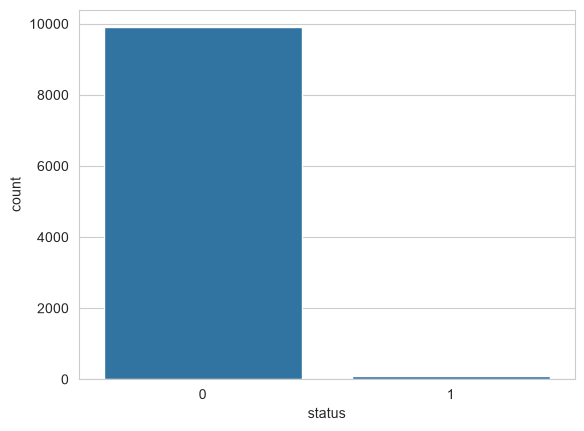

In [89]:
df["status"].value_counts()

round(df["status"].value_counts(normalize=True) * 100, 2)

sns.countplot(data=df, x="status")
plt.show()

### **2. Preparación de Datos**
### **2.1. Selección de variables predictoras**

In [90]:
X = df.drop(columns=["status"])

### **2.2. Variable Objetivo**

In [91]:
# Variable objetivo
y = df["status"]

# Variables predictoras
X = df.drop(
    columns=[
        "status",
        "status_label"
    ],
    errors="ignore"
)

# Mantener únicamente variables numéricas
X = X.select_dtypes(include=np.number)

print(X.columns.tolist())
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

['cpu_utilization', 'memory_usage', 'disk_io', 'network_latency', 'process_count', 'thread_count', 'context_switches', 'cache_miss_rate', 'temperature', 'power_consumption', 'uptime', 'cpu_utilization_norm', 'memory_usage_norm', 'network_latency_norm', 'temperature_norm', 'power_consumption_norm', 'system_pressure_score']
(10000, 17)


#### **2.4. Escalado**

In [92]:
# StandardScaler ya fue importado en la celda 2

scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=np.number).columns

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index,
)
print("Escalado de características completado.")
print(f"Dimensiones de X_train_scaled: {X_train_scaled.shape}")

Escalado de características completado.
Dimensiones de X_train_scaled: (8000, 17)


### **3. Entrenamiento de Modelos**
#### **3.1. Modelo Base: Regresión Logística**

In [93]:
# Ajuste del modelo de regresión logística
modelo_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
# Imprimir mensaje indicando que se está ajustando el modelo de regresión logística
print("Ajuste del modelo de regresión logística...")
modelo_lr.fit(X_train_scaled, y_train)
print("Coeficientes:", len(modelo_lr.coef_[0]))
print("Intercepto:", modelo_lr.intercept_[0])

Ajuste del modelo de regresión logística...
Coeficientes: 17
Intercepto: -20.83137430479032


In [94]:
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]
print("Evaluación del modelo de regresión logística...:")
print(classification_report(y_test, y_pred_lr))

Evaluación del modelo de regresión logística...:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1981
           1       0.24      1.00      0.39        19

    accuracy                           0.97      2000
   macro avg       0.62      0.99      0.69      2000
weighted avg       0.99      0.97      0.98      2000



#### **3.2. Modelo Avanzado: Random Forest**

In [95]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)
print("Número de árboles:", len(modelo_rf.estimators_))

Número de árboles: 200


In [96]:
y_pred_rf = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]
print("Evaluación del modelo de Random Forest...:")
print(classification_report(y_test, y_pred_rf))

Evaluación del modelo de Random Forest...:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000



#### **3.3. Red Neuronal: MLPClassifier**

In [97]:
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

modelo_mlp.fit(X_train_scaled, y_train)
print("Iteraciones realizadas:", modelo_mlp.n_iter_)

Iteraciones realizadas: 109


In [98]:
y_pred_mlp = modelo_mlp.predict(X_test_scaled)
y_proba_mlp = modelo_mlp.predict_proba(X_test_scaled)[:, 1]
print("Evaluación del modelo de MLP...:")
print(classification_report(y_test, y_pred_mlp))

Evaluación del modelo de MLP...:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       0.81      0.68      0.74        19

    accuracy                           1.00      2000
   macro avg       0.90      0.84      0.87      2000
weighted avg       1.00      1.00      1.00      2000



#### **3.4. Comprobación rápida de predicciones**

In [99]:
print("Regresión Logística")
print(pd.Series(y_pred_lr).value_counts())

print("\nRandom Forest")
print(pd.Series(y_pred_rf).value_counts())

print("\nRed Neuronal MLP")
print(pd.Series(y_pred_mlp).value_counts())

Regresión Logística
0    1922
1      78
Name: count, dtype: int64

Random Forest
0    1982
1      18
Name: count, dtype: int64

Red Neuronal MLP
0    1984
1      16
Name: count, dtype: int64


### **4. Análisis de Entrenamiento de Modelos Predictivos**

En esta fase se entrenan diferentes modelos de clasificación supervisada con el objetivo de predecir el estado del sistema a partir de las métricas de rendimiento de la infraestructura IT.

Se utilizan tres enfoques:

- Regresión Logística como modelo base interpretable.
- Random Forest como modelo avanzado basado en árboles de decisión.
- Red Neuronal MLP como aproximación de aprendizaje automático más flexible.

Debido al fuerte desbalanceo de la variable objetivo, los modelos tradicionales se configuran con `class_weight="balanced"` para dar mayor peso a la clase minoritaria correspondiente a los incidentes.

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [107]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [108]:
confusion_matrix(y_test, y_pred_rf)

array([[1981,    0],
       [   1,   18]])

#### **4. División Train/Test**

In [111]:
# División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Conjuntos de entrenamiento y prueba creados.")
print(f"Dimensiones de X_train: {X_train.shape}, Dimensiones de X_test: {X_test.shape}")

Conjuntos de entrenamiento y prueba creados.
Dimensiones de X_train: (8000, 17), Dimensiones de X_test: (2000, 17)


### **5. Escalado**

In [113]:
# Escalado de características
scaler = StandardScaler()

# Ajuste del modelo de regresión logística
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Escalado de características completado.")
print(f"Dimensiones de X_train_scaled: {X_train_scaled.shape}, Dimensiones de X_test_scaled: {X_test_scaled.shape}")

Escalado de características completado.
Dimensiones de X_train_scaled: (8000, 17), Dimensiones de X_test_scaled: (2000, 17)


### **6. Modelos predictivos**
### **6.1. Modelo 1: Regresión Logística**
#### **6.1.1. Predicción**

In [115]:
modelo_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modelo_lr.fit(X_train_scaled, y_train)
print("Coeficientes:", len(modelo_lr.coef_[0]))

Coeficientes: 17


#### **6.1.2. Evaluación**

In [116]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1981
           1       0.24      1.00      0.39        19

    accuracy                           0.97      2000
   macro avg       0.62      0.99      0.69      2000
weighted avg       0.99      0.97      0.98      2000



#### **6.1.3. Matríz de Confusión**

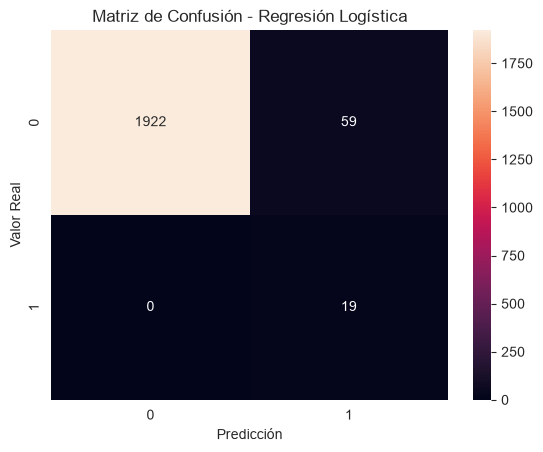

In [117]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

#### **6.2. Modelo 2: Random Forest**
#### **6.2.1. Entrenamiento**

In [119]:
modelo_rf.fit(X_train, y_train)
print("Número de árboles:", len(modelo_rf.estimators_))

Número de árboles: 200


#### **6.2.2. Predicción**

In [123]:
y_pred_rf = modelo_rf.predict(X_test)
print(classification_report(
    y_test,
    y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000



#### **6.2.3. Evaluación**

In [121]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1981
           1       1.00      0.95      0.97        19

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.99      2000
weighted avg       1.00      1.00      1.00      2000



#### **6.2.4. Matríz de Confusión**

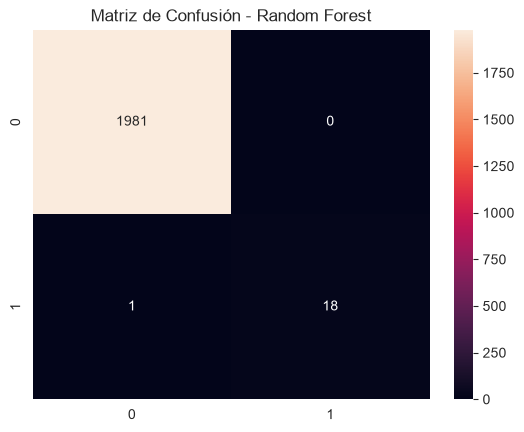

In [122]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión - Random Forest")
plt.show()

### **8. Modelo 3: Red Neuronal MLP**